# FASE 1. Construccion del detector

## 1. Carga de datos y modelo

In [22]:
import pandas as pd
import numpy as np

import joblib

import matplotlib.pyplot as plt

In [23]:
dataset = pd.read_csv(
    "../data/plant1_preprocessed.csv"
)

dataset = dataset[
    dataset["IRRADIATION"] > 0
].copy()

dataset.head()

,DATE_TIME,AC_POWER,AMBIENT_TEMPERATURE,MODULE_TEMPERATURE,IRRADIATION,HOUR
23,2020-05-15 05:45:00,0.000000,24.289211,23.096692,0.000863,5
24,2020-05-15 06:00:00,90.929167,24.088446,22.206757,0.005887,6
25,2020-05-15 06:15:00,593.338690,24.011635,22.353459,0.022282,6
26,2020-05-15 06:30:00,1480.194643,23.976731,22.893282,0.049410,6
27,2020-05-15 06:45:00,2790.448214,24.218990,24.442444,0.095394,6


In [24]:
rf = joblib.load(
    "../models/random_forest_plant1.pkl"
)

## 2. Generación de predicciones


In [25]:
X = dataset[
    [
        "AMBIENT_TEMPERATURE",
        "MODULE_TEMPERATURE",
        "IRRADIATION",
        "HOUR"
    ]
]

In [26]:
dataset["EXPECTED_POWER"] = rf.predict(X)

In [27]:
dataset[
    [
        "AC_POWER",
        "EXPECTED_POWER"
    ]
].head()

,AC_POWER,EXPECTED_POWER
23,0.000000,0.000000
24,90.929167,89.960583
25,593.338690,624.303738
26,1480.194643,1495.903125
27,2790.448214,2821.308946


## 3. Cálculo del error de predicción


In [28]:
dataset["ERROR"] = (
    dataset["AC_POWER"]
    -
    dataset["EXPECTED_POWER"]
)

In [29]:
dataset["ERROR_ABS"] = (
    dataset["ERROR"]
    .abs()
)

In [30]:
dataset["ERROR_PCT"] = (
    dataset["ERROR_ABS"]
    /
    dataset["EXPECTED_POWER"]
) * 100

## 4. Análisis estadístico del error


In [31]:
dataset["ERROR_PCT"].describe()

count    1706.000000
mean        4.163255
std        11.565413
min         0.002209
25%         0.771875
50%         1.698789
75%         3.550434
max       100.000000
Name: ERROR_PCT, dtype: float64

In [32]:
dataset["ERROR_PCT"].quantile(
    [0.90, 0.95, 0.99]
)

0.90      7.215339
0.95     11.040336
0.99    100.000000
Name: ERROR_PCT, dtype: float64

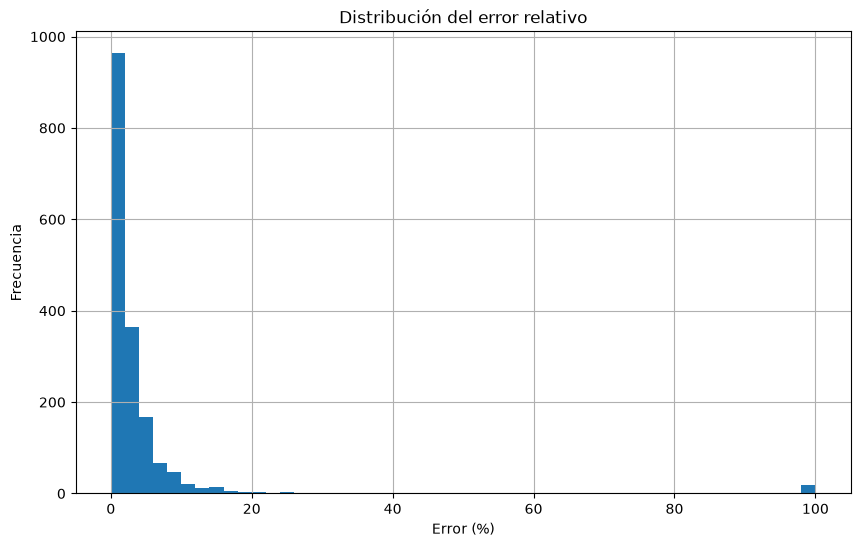

In [33]:
plt.figure(figsize=(10,6))

dataset["ERROR_PCT"].hist(
    bins=50
)

plt.xlabel("Error (%)")
plt.ylabel("Frecuencia")
plt.title("Distribución del error relativo")

plt.show()

In [34]:
error_analysis = dataset[
    dataset["EXPECTED_POWER"] > 1000
].copy()

In [35]:
error_analysis["ERROR_PCT"].describe()

count    1554.000000
mean        2.525069
std         2.964563
min         0.002209
25%         0.729139
50%         1.589743
75%         3.174788
max        25.144636
Name: ERROR_PCT, dtype: float64

In [36]:
error_analysis["ERROR_PCT"].quantile(
    [0.90, 0.95, 0.99]
)

0.90     5.731436
0.95     8.134336
0.99    14.603453
Name: ERROR_PCT, dtype: float64

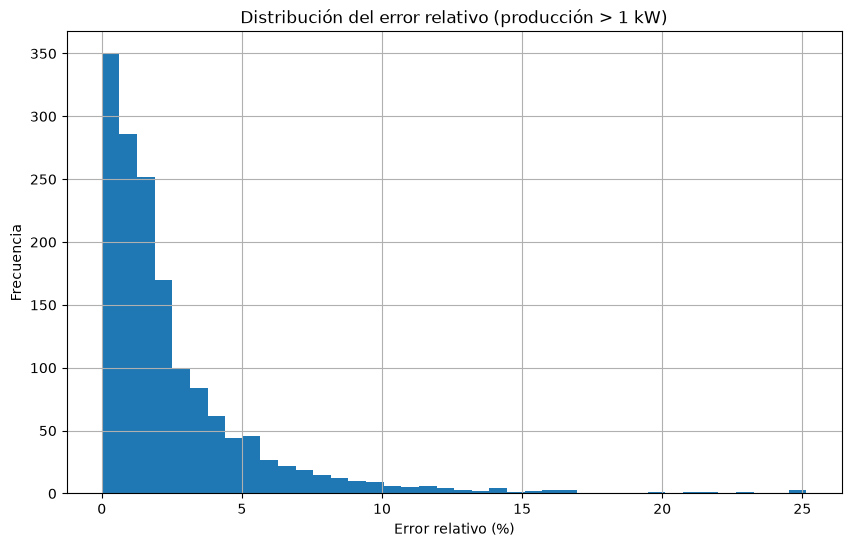

In [37]:
plt.figure(figsize=(10,6))

error_analysis["ERROR_PCT"].hist(
    bins=40
)

plt.xlabel("Error relativo (%)")
plt.ylabel("Frecuencia")
plt.title("Distribución del error relativo (producción > 1 kW)")

plt.show()

## 5. Definición de umbrales


In [38]:
THRESHOLD = error_analysis["ERROR_PCT"].quantile(0.95)

print(f"Umbral de detección: {THRESHOLD:.2f}%")

Umbral de detección: 8.13%


In [39]:
dataset["OVER_THRESHOLD"] = (
    dataset["ERROR_PCT"] > THRESHOLD
)

In [40]:
dataset[
    [
        "ERROR_PCT",
        "OVER_THRESHOLD"
    ]
].head()

,ERROR_PCT,OVER_THRESHOLD
23,NaN,False
24,1.076675,False
25,4.959933,False
26,1.050100,False
27,1.093844,False


In [41]:
dataset["OVER_THRESHOLD"].value_counts()

OVER_THRESHOLD
False    1612
True      142
Name: count, dtype: int64

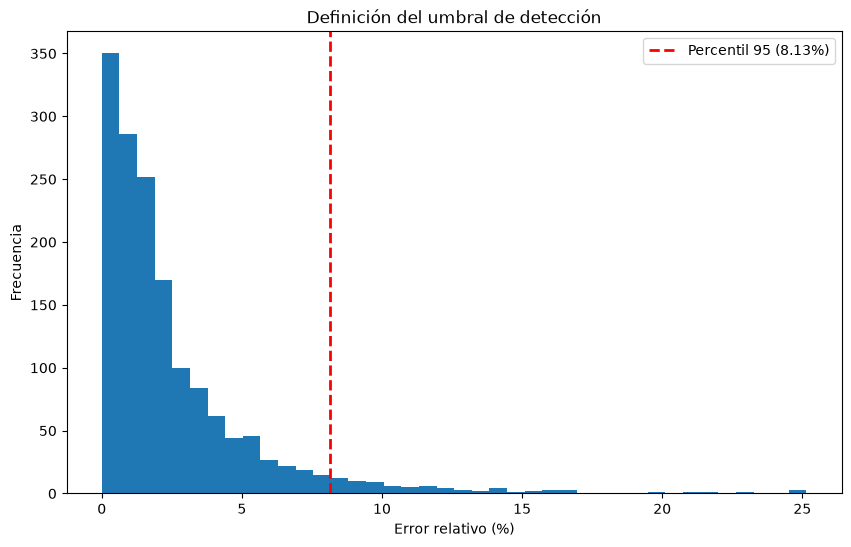

In [42]:
plt.figure(figsize=(10,6))

plt.hist(
    error_analysis["ERROR_PCT"],
    bins=40
)

plt.axvline(
    THRESHOLD,
    color="red",
    linestyle="--",
    linewidth=2,
    label=f"Percentil 95 ({THRESHOLD:.2f}%)"
)

plt.xlabel("Error relativo (%)")
plt.ylabel("Frecuencia")
plt.title("Definición del umbral de detección")

plt.legend()

plt.show()

# FASE 2. Validacion del detector

## 6. Generación de anomalías sintéticas


In [63]:
validation_dataset = error_analysis.copy()

In [64]:
validation_dataset.info()

<class 'pandas.DataFrame'>
Index: 1554 entries, 26 to 3133
Data columns (total 10 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   DATE_TIME            1554 non-null   str    
 1   AC_POWER             1554 non-null   float64
 2   AMBIENT_TEMPERATURE  1554 non-null   float64
 3   MODULE_TEMPERATURE   1554 non-null   float64
 4   IRRADIATION          1554 non-null   float64
 5   HOUR                 1554 non-null   int64  
 6   EXPECTED_POWER       1554 non-null   float64
 7   ERROR                1554 non-null   float64
 8   ERROR_ABS            1554 non-null   float64
 9   ERROR_PCT            1554 non-null   float64
dtypes: float64(8), int64(1), str(1)
memory usage: 133.5 KB


In [65]:
validation_dataset["OBSERVED_POWER"] = validation_dataset["AC_POWER"]

In [66]:
validation_dataset["SIMULATED_ANOMALY"] = False

In [67]:
def insert_anomaly(dataframe, start, end, loss_percentage):
    """
    Introduce una pérdida de producción en un intervalo temporal.

    Parámetros
    ----------
    dataframe : DataFrame
    start : str
    end : str
    loss_percentage : float
    """

    mask = (
        (dataframe["DATE_TIME"] >= start)
        &
        (dataframe["DATE_TIME"] <= end)
    )

    dataframe.loc[mask, "OBSERVED_POWER"] *= (
        1 - loss_percentage / 100
    )

    dataframe.loc[mask, "SIMULATED_ANOMALY"] = True

    return dataframe

In [68]:
validation_dataset = insert_anomaly(
    validation_dataset,
    start="2020-05-22 11:00:00",
    end="2020-05-22 13:00:00",
    loss_percentage=10
)

In [69]:
validation_dataset["ERROR"] = (
    validation_dataset["OBSERVED_POWER"]
    -
    validation_dataset["EXPECTED_POWER"]
)

In [70]:
validation_dataset["ERROR_ABS"] = (
    validation_dataset["ERROR"].abs()
)

In [71]:
validation_dataset["ERROR_PCT"] = (
    validation_dataset["ERROR_ABS"]
    /
    validation_dataset["EXPECTED_POWER"]
) * 100

In [72]:
validation_dataset["OVER_THRESHOLD"] = (
    validation_dataset["ERROR_PCT"] > THRESHOLD
)

In [73]:
validation_dataset[
    validation_dataset["SIMULATED_ANOMALY"]
].head()

,DATE_TIME,AC_POWER,AMBIENT_TEMPERATURE,MODULE_TEMPERATURE,IRRADIATION,HOUR,EXPECTED_POWER,ERROR,ERROR_ABS,ERROR_PCT,OBSERVED_POWER,SIMULATED_ANOMALY,OVER_THRESHOLD
651,2020-05-22 11:00:00,17375.292857,28.880099,50.248248,0.608489,11,17951.479329,-2313.715757,2313.715757,12.888719,15637.763571,True,True
652,2020-05-22 11:15:00,16535.286071,28.860333,44.390485,0.553059,11,16689.231743,-1807.474279,1807.474279,10.830183,14881.757464,True,True
653,2020-05-22 11:30:00,27308.166070,29.774949,52.591133,0.999310,11,25547.548893,-970.199430,970.199430,3.797622,24577.349463,True,False
654,2020-05-22 11:45:00,26879.828571,30.584066,60.629063,1.047775,11,26835.640130,-2643.794416,2643.794416,9.851803,24191.845714,True,True
655,2020-05-22 12:00:00,27677.362499,30.824836,62.212090,1.031861,12,26852.680075,-1943.053826,1943.053826,7.235977,24909.626249,True,False


In [74]:
validation_dataset["OVER_THRESHOLD"].value_counts()

OVER_THRESHOLD
False    1470
True       84
Name: count, dtype: int64

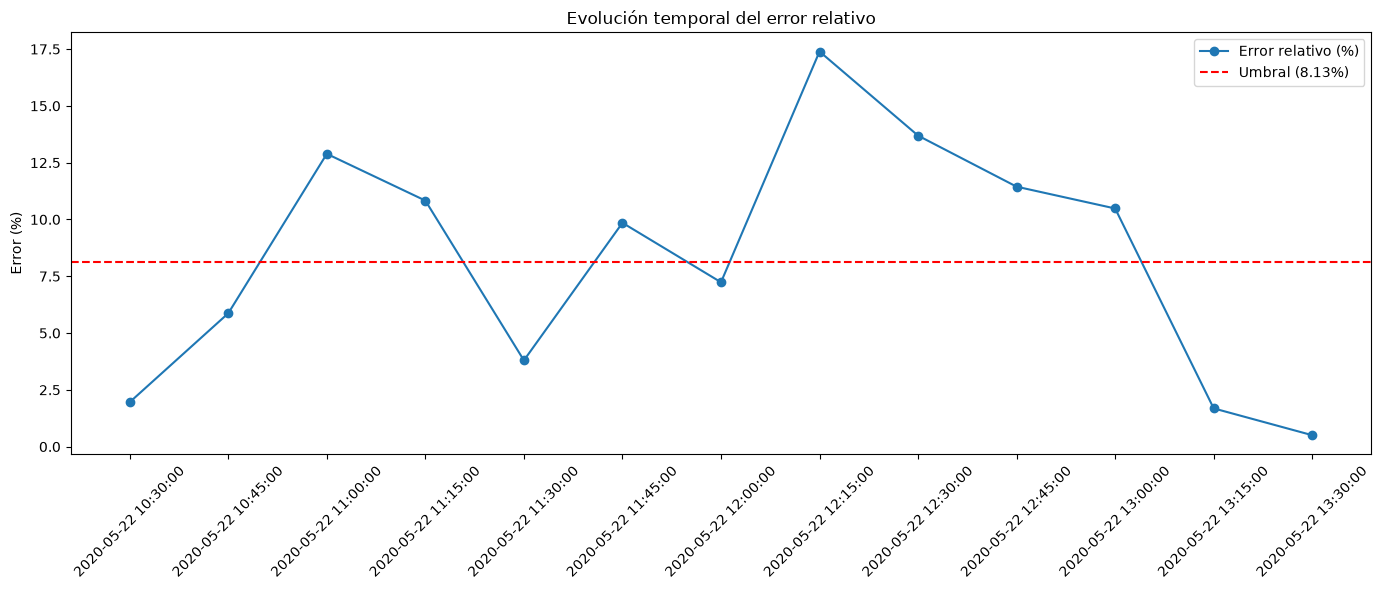

In [75]:
plot_data = validation_dataset[
    (
        validation_dataset["DATE_TIME"] >= "2020-05-22 10:30:00"
    )
    &
    (
        validation_dataset["DATE_TIME"] <= "2020-05-22 13:30:00"
    )
]

plt.figure(figsize=(14,6))

plt.plot(
    plot_data["DATE_TIME"],
    plot_data["ERROR_PCT"],
    marker="o",
    label="Error relativo (%)"
)

plt.axhline(
    THRESHOLD,
    color="red",
    linestyle="--",
    label=f"Umbral ({THRESHOLD:.2f}%)"
)

plt.xticks(rotation=45)

plt.ylabel("Error (%)")

plt.title("Evolución temporal del error relativo")

plt.legend()

plt.tight_layout()

plt.show()

## 7. Detección de anomalías


In [76]:
validation_dataset = validation_dataset.sort_values(
    "DATE_TIME"
).reset_index(drop=True)

In [77]:
validation_dataset["ERROR_PCT_MOVING"] = (
    validation_dataset["ERROR_PCT"]
    .rolling(window=4)
    .mean()
)

In [78]:
validation_dataset["ANOMALY_DETECTED"] = (
    validation_dataset["ERROR_PCT_MOVING"] > THRESHOLD
)

In [79]:
validation_dataset["ANOMALY_DETECTED"].value_counts()

ANOMALY_DETECTED
False    1519
True       35
Name: count, dtype: int64

In [80]:
validation_dataset[
    validation_dataset["SIMULATED_ANOMALY"]
]

,DATE_TIME,AC_POWER,AMBIENT_TEMPERATURE,MODULE_TEMPERATURE,IRRADIATION,HOUR,EXPECTED_POWER,ERROR,ERROR_ABS,ERROR_PCT,OBSERVED_POWER,SIMULATED_ANOMALY,OVER_THRESHOLD,ERROR_PCT_MOVING,ANOMALY_DETECTED
314,2020-05-22 11:00:00,17375.292857,28.880099,50.248248,0.608489,11,17951.479329,-2313.715757,2313.715757,12.888719,15637.763571,True,True,6.542900,False
315,2020-05-22 11:15:00,16535.286071,28.860333,44.390485,0.553059,11,16689.231743,-1807.474279,1807.474279,10.830183,14881.757464,True,True,7.887210,False
316,2020-05-22 11:30:00,27308.166070,29.774949,52.591133,0.999310,11,25547.548893,-970.199430,970.199430,3.797622,24577.349463,True,False,8.346839,True
317,2020-05-22 11:45:00,26879.828571,30.584066,60.629063,1.047775,11,26835.640130,-2643.794416,2643.794416,9.851803,24191.845714,True,True,9.342082,True
318,2020-05-22 12:00:00,27677.362499,30.824836,62.212090,1.031861,12,26852.680075,-1943.053826,1943.053826,7.235977,24909.626249,True,False,7.928896,False
319,2020-05-22 12:15:00,21636.850000,30.752173,57.925578,0.811755,12,23573.125147,-4099.960147,4099.960147,17.392518,19473.165000,True,True,9.569480,True
320,2020-05-22 12:30:00,20300.387500,30.917711,54.400393,0.762447,12,21168.249905,-2897.901155,2897.901155,13.689848,18270.348750,True,True,12.042537,True
321,2020-05-22 12:45:00,24282.625001,31.413285,55.893387,0.917253,12,24678.349167,-2823.986666,2823.986666,11.443175,21854.362501,True,True,12.440380,True
322,2020-05-22 13:00:00,23066.469049,31.318955,54.857410,0.814844,13,23190.901166,-2431.079022,2431.079022,10.482900,20759.822144,True,True,13.252110,True


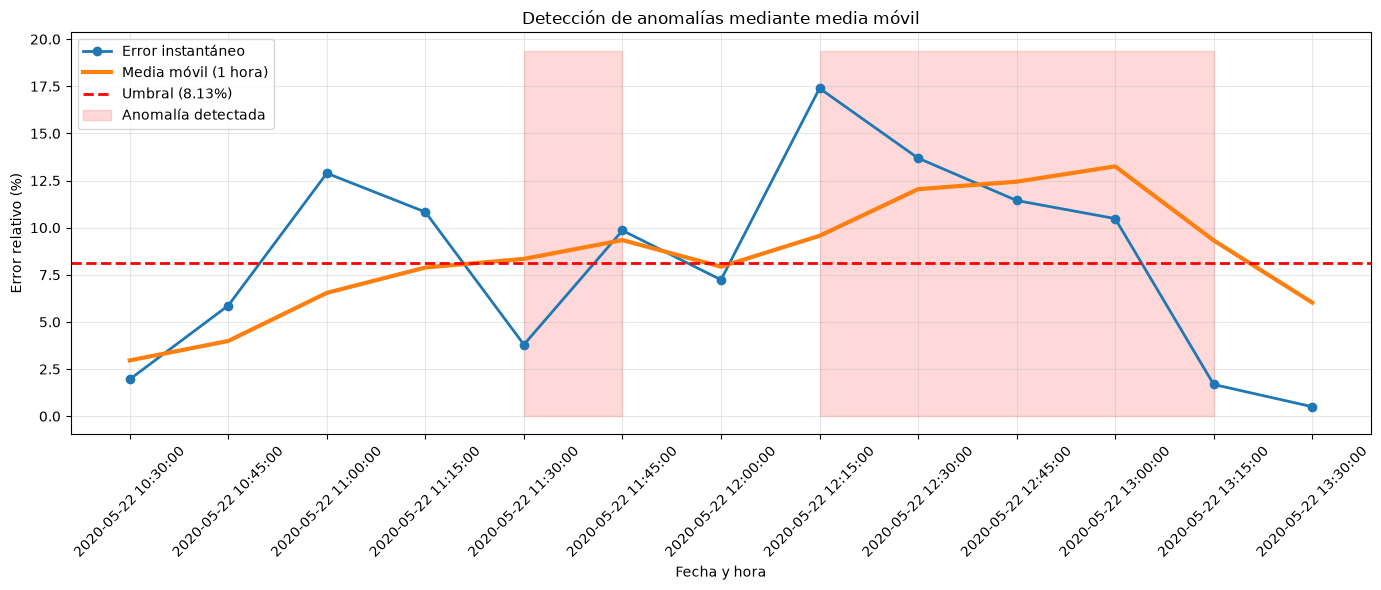

In [81]:
plot_data = validation_dataset[
    (validation_dataset["DATE_TIME"] >= "2020-05-22 10:30:00") &
    (validation_dataset["DATE_TIME"] <= "2020-05-22 13:30:00")
]

plt.figure(figsize=(14,6))

# Error instantáneo
plt.plot(
    plot_data["DATE_TIME"],
    plot_data["ERROR_PCT"],
    marker="o",
    linewidth=2,
    label="Error instantáneo"
)

# Media móvil
plt.plot(
    plot_data["DATE_TIME"],
    plot_data["ERROR_PCT_MOVING"],
    linewidth=3,
    label="Media móvil (1 hora)"
)

# Umbral
plt.axhline(
    THRESHOLD,
    color="red",
    linestyle="--",
    linewidth=2,
    label=f"Umbral ({THRESHOLD:.2f}%)"
)

# Intervalos detectados como anomalía
plt.fill_between(
    plot_data["DATE_TIME"],
    0,
    plot_data["ERROR_PCT"].max()+2,
    where=plot_data["ANOMALY_DETECTED"],
    color="red",
    alpha=0.15,
    label="Anomalía detectada"
)

plt.xticks(rotation=45)
plt.ylabel("Error relativo (%)")
plt.xlabel("Fecha y hora")
plt.title("Detección de anomalías mediante media móvil")

plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()

plt.show()

## 8. Resultados

In [84]:
pd.crosstab(
    validation_dataset["SIMULATED_ANOMALY"],
    validation_dataset["ANOMALY_DETECTED"],
    margins=True
)

ANOMALY_DETECTED,False,True,All
SIMULATED_ANOMALY,,,
False,1516,29,1545
True,3,6,9
All,1519,35,1554


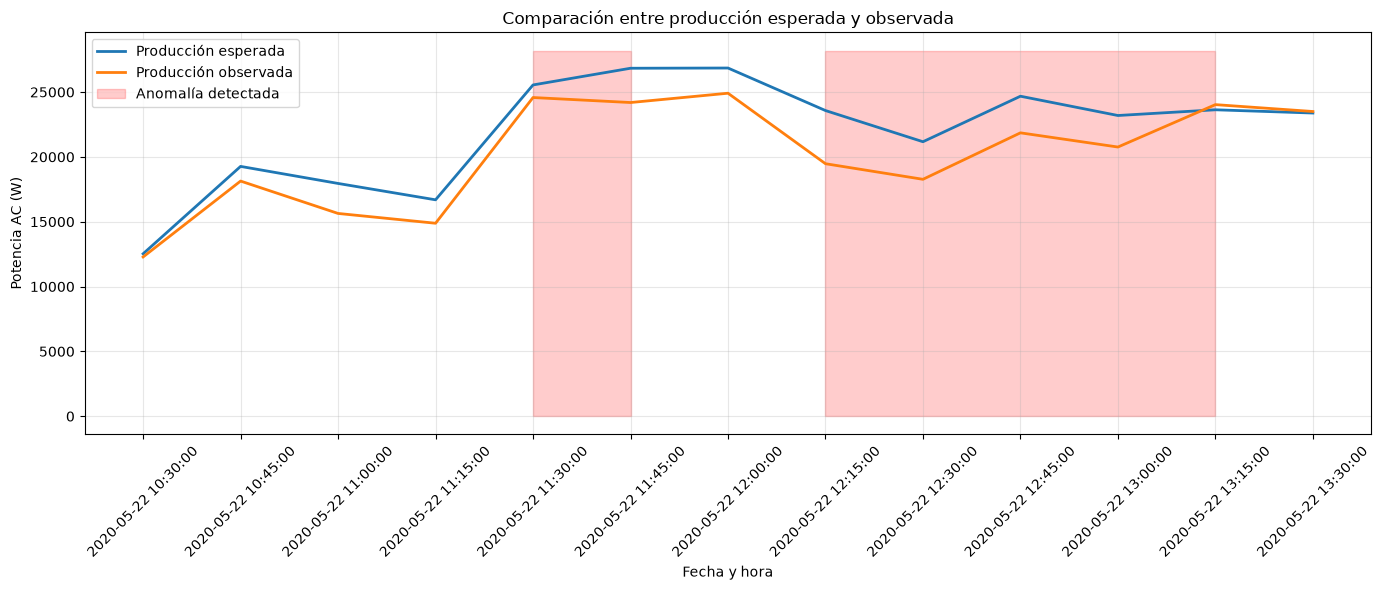

In [85]:
plot_data = validation_dataset[
    (validation_dataset["DATE_TIME"] >= "2020-05-22 10:30:00") &
    (validation_dataset["DATE_TIME"] <= "2020-05-22 13:30:00")
]

plt.figure(figsize=(14,6))

plt.plot(
    plot_data["DATE_TIME"],
    plot_data["EXPECTED_POWER"],
    linewidth=2,
    label="Producción esperada"
)

plt.plot(
    plot_data["DATE_TIME"],
    plot_data["OBSERVED_POWER"],
    linewidth=2,
    label="Producción observada"
)

plt.fill_between(
    plot_data["DATE_TIME"],
    0,
    plot_data["EXPECTED_POWER"].max()*1.05,
    where=plot_data["ANOMALY_DETECTED"],
    alpha=0.2,
    color="red",
    label="Anomalía detectada"
)

plt.xticks(rotation=45)
plt.ylabel("Potencia AC (W)")
plt.xlabel("Fecha y hora")
plt.title("Comparación entre producción esperada y observada")

plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()

plt.show()

In [87]:
validation_dataset.to_csv(
    "validation_dataset.csv",
    index=False
)